In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Proyección pinhole

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def proyectar_pinhole(puntos_3d, f):
    """
    Proyección perspectiva básica del modelo pinhole.

    puntos_3d: array (N,3)
    f: distancia focal
    """
    X = puntos_3d[:, 0]
    Y = puntos_3d[:, 1]
    Z = puntos_3d[:, 2]

    x = f * (X / Z)
    y = f * (Y / Z)

    return np.vstack((x, y)).T

## Creación de cubo

In [3]:
def crear_cubo(tamano=1, centro=(0,0,5)):
    cx, cy, cz = centro
    t = tamano / 2

    vertices = np.array([
        [cx-t, cy-t, cz-t],
        [cx+t, cy-t, cz-t],
        [cx+t, cy+t, cz-t],
        [cx-t, cy+t, cz-t],
        [cx-t, cy-t, cz+t],
        [cx+t, cy-t, cz+t],
        [cx+t, cy+t, cz+t],
        [cx-t, cy+t, cz+t],
    ])
    return vertices

## Dibujo de cubo

In [4]:
def dibujar_cubo_2d(puntos_2d, titulo="Proyección", limite=3):
    aristas = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]

    fig, ax = plt.subplots(figsize=(6,6))

    for a in aristas:
        p1 = puntos_2d[a[0]]
        p2 = puntos_2d[a[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]])

    ax.scatter(puntos_2d[:,0], puntos_2d[:,1])

    ax.set_aspect('equal', adjustable='box')

    # Fijar límites manualmente
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)

    ax.set_xlabel("x'")
    ax.set_ylabel("y'")
    ax.set_title(titulo)
    ax.invert_yaxis()
    ax.grid(True)

    plt.show()

## Efecto
Se realiza  proyección con dos distancias focales distintas

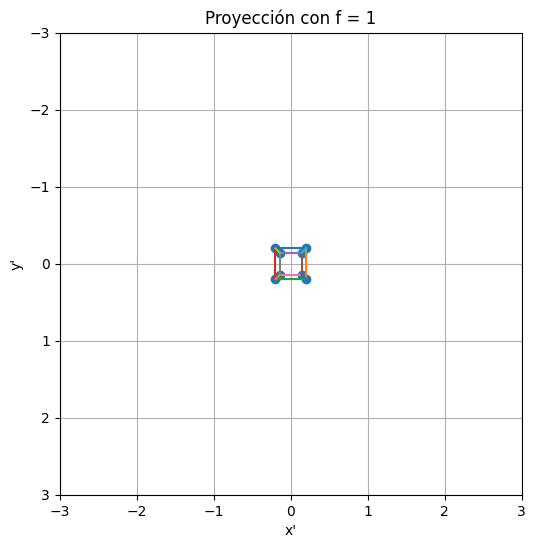

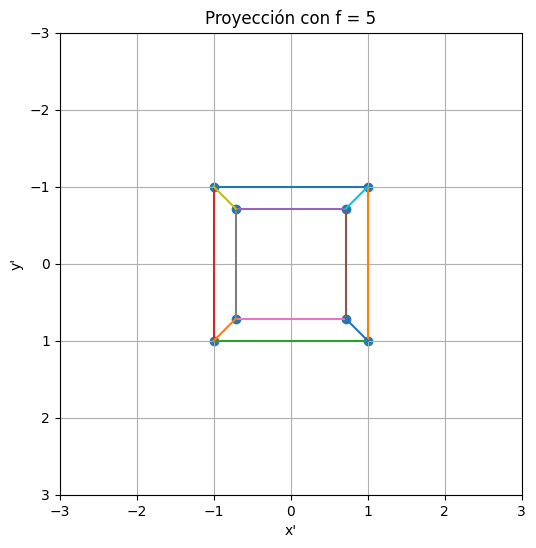

In [5]:
# Crear cubo
cubo = crear_cubo(tamano=2, centro=(0,0,6))

# Focal pequeña
f1 = 1
proy1 = proyectar_pinhole(cubo, f1)
dibujar_cubo_2d(proy1, f"Proyección con f = {f1}")

# Focal grande
f2 = 5
proy2 = proyectar_pinhole(cubo, f2)
dibujar_cubo_2d(proy2, f"Proyección con f = {f2}")

## Parámetros intrínsecos
```
[fx  0  cx]
[0  fy  cy]
[0   0   1]
```

In [6]:
def proyectar_con_K(puntos_3d, K):
    """
    Proyección usando matriz intrínseca K.
    puntos_3d: (N,3)
    K: matriz intrínseca 3x3
    """
    puntos_3d = puntos_3d.T  # (3,N)

    # Coordenadas normalizadas
    puntos_norm = puntos_3d / puntos_3d[2, :]

    # Aplicar matriz intrínseca
    puntos_img = K @ puntos_norm

    return puntos_img[:2, :].T

In [7]:
ancho = 800
alto = 600

fx = 800
fy = 800
cx = ancho / 2
cy = alto / 2

K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

In [8]:
cubo = crear_cubo(tamano=2, centro=(0,0,6))
proy = proyectar_con_K(cubo, K)

In [9]:
def dibujar_imagen(puntos_2d, ancho, alto, titulo="Proyección con K"):
    aristas = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]

    fig, ax = plt.subplots(figsize=(8,6))

    for a in aristas:
        p1 = puntos_2d[a[0]]
        p2 = puntos_2d[a[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]])

    ax.scatter(puntos_2d[:,0], puntos_2d[:,1])

    ax.set_xlim(0, ancho)
    ax.set_ylim(alto, 0)  # invertir eje Y como imagen
    ax.set_title(titulo)
    ax.set_aspect('equal')
    ax.grid(True)

    plt.show()

### fx y fy grande

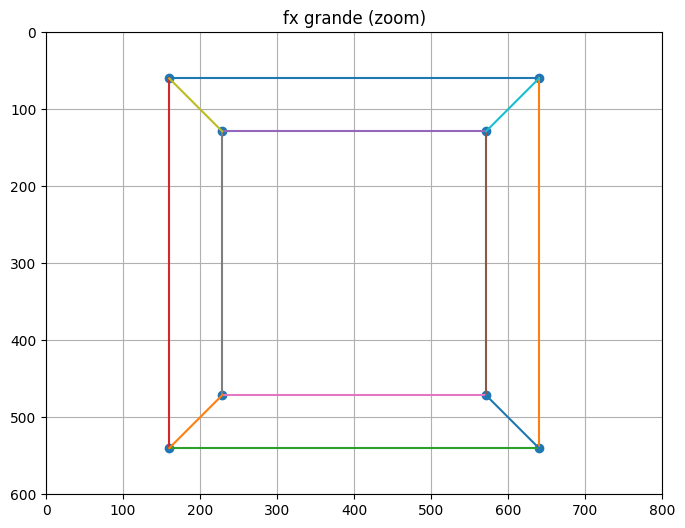

In [10]:
fx = 1200
fy = 1200
K_zoom = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

proy_zoom = proyectar_con_K(cubo, K_zoom)
dibujar_imagen(proy_zoom, ancho, alto, "fx grande (zoom)")

### fx!=fy

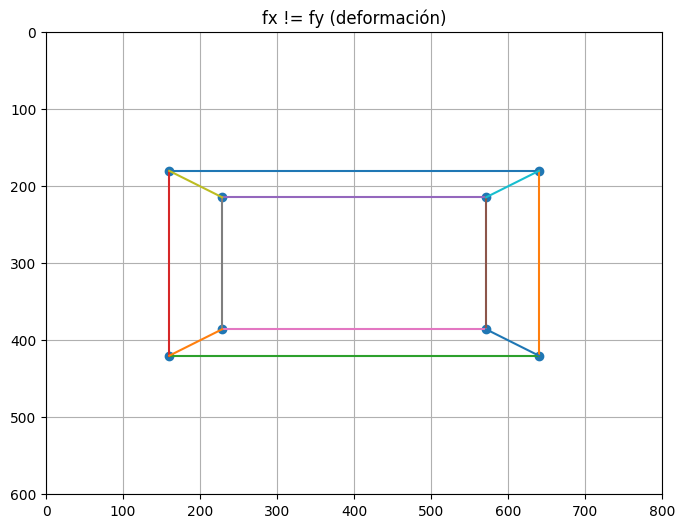

In [11]:
fx = 1200
fy = 600

K_dist = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

proy_dist = proyectar_con_K(cubo, K_dist)
dibujar_imagen(proy_dist, ancho, alto, "fx != fy (deformación)")

### Cambiar centro óptico

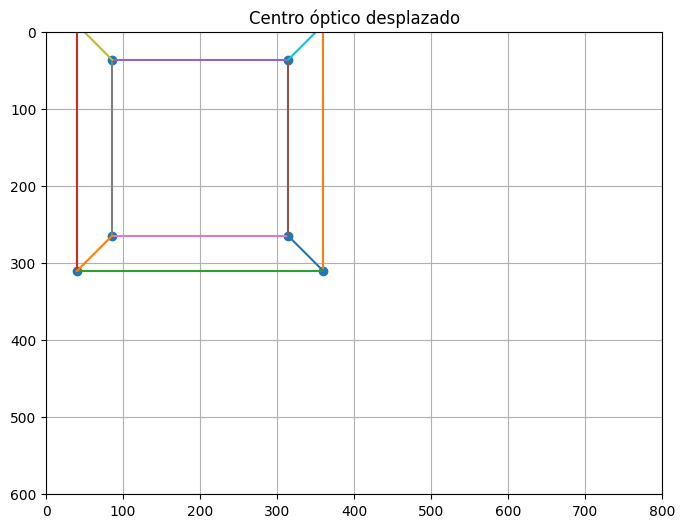

In [12]:
cx = 200
cy = 150

K_shift = np.array([
    [800, 0, cx],
    [0, 800, cy],
    [0, 0, 1]
])

proy_shift = proyectar_con_K(cubo, K_shift)
dibujar_imagen(proy_shift, ancho, alto, "Centro óptico desplazado")

## Parámetros extrínsecos

In [13]:
def transformar_extrinsecos(puntos_3d, R, t):
    """
    Aplica transformación mundo → cámara.
    
    puntos_3d: (N,3)
    R: (3,3)
    t: (3,1)
    """
    return (R @ puntos_3d.T + t).T

### Rotación en y

In [14]:
def rotacion_y(theta):
    return np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

### Pipeline completo

In [15]:
def proyectar_completo(puntos_3d, K, R, t):
    # Mundo → Cámara
    puntos_cam = transformar_extrinsecos(puntos_3d, R, t)
    
    # Proyección con intrínsecos
    puntos_img = proyectar_con_K(puntos_cam, K)
    
    return puntos_img

### Simular movimiento de cámara

#### Rotación de cámara

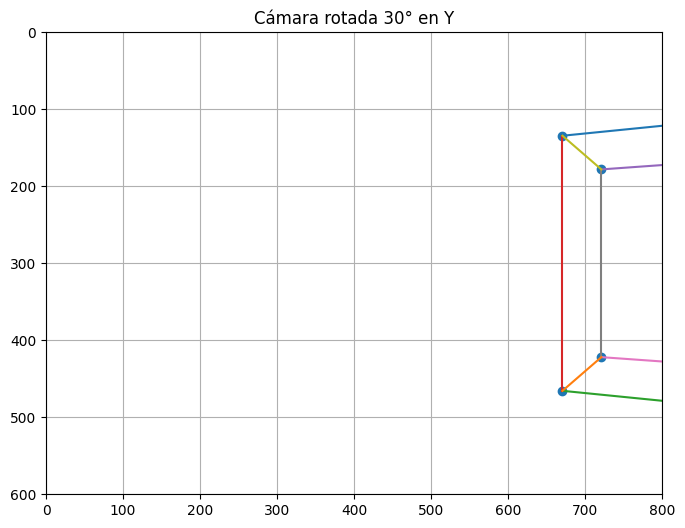

In [16]:
theta = np.radians(30)
R = rotacion_y(theta)
t = np.array([[0], [0], [0]])

proy_rot = proyectar_completo(cubo, K, R, t)
dibujar_imagen(proy_rot, ancho, alto, "Cámara rotada 30° en Y")

### Traslación de cámara

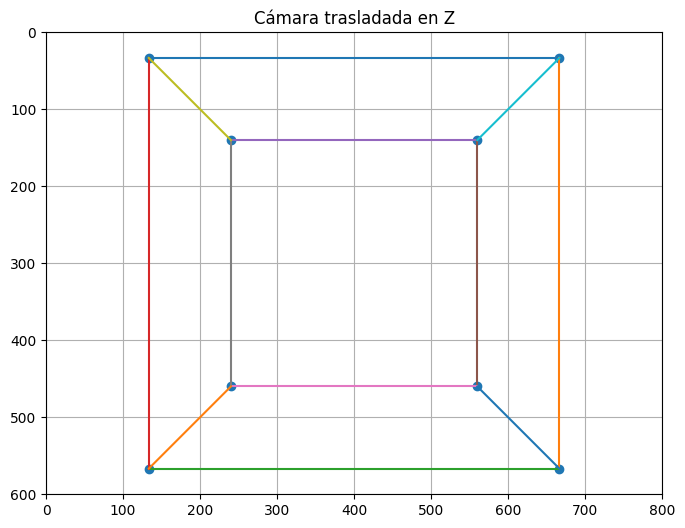

In [17]:
R = np.eye(3)
t = np.array([[0], [0], [-2]])  # cámara avanza

proy_trans = proyectar_completo(cubo, K, R, t)
dibujar_imagen(proy_trans, ancho, alto, "Cámara trasladada en Z")

## Calibración de cámara con patrón

In [54]:
import cv2
import glob

imgs_path = "./../calibration_images"

#parametros del patron
chessboard_size = (8,6)
square_size = 1.0

objp = np.zeros((np.prod(chessboard_size),3), np.float32)
objp[:,:2] = np.indices(chessboard_size).T.reshape(-1,2)
objp *= square_size

objpoints = []
imgpoints = []

#todas las imagenes de checkerboard son jpeg, la de distorsion es jpg
images = glob.glob(imgs_path + "/*.jpeg")
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)

    if ret:
        objpoints.append(objp)
        imgpoints.append(corners)

ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)

print("Matriz intrínseca:\n", K)
print("Coeficientes distorsión:\n", dist)

np.savez("calibracion.npz", K=K, dist=dist)

Matriz intrínseca:
 [[1.24953842e+03 0.00000000e+00 6.41007951e+02]
 [0.00000000e+00 1.17797383e+03 6.85636048e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes distorsión:
 [[-2.18250644e-01  7.43140594e-01 -2.13930368e-02 -1.52304163e-04
  -9.35825560e-01]]


# Correción de distorsión

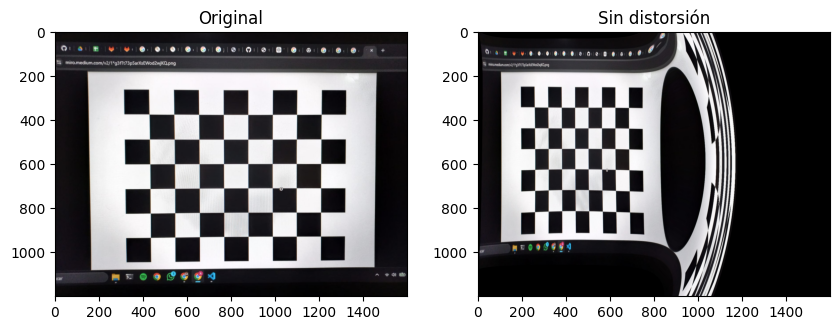

In [52]:
img = cv2.imread(imgs_path + "/2.jpeg")
h, w = img.shape[:2]

#deshacer distorcion
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w,h), 1, (w,h))
dst = cv2.undistort(img, K, dist, None, newcameramtx)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
plt.title("Sin distorsión")

plt.show()

In [53]:
total_error = 0

for i in range(len(objpoints)):
    #proyeccion basada en los parametros obtenidos 
    imgpoints2, _ = cv2.projectPoints(
        objpoints[i], rvecs[i], tvecs[i], K, dist
    )
    #distancia entre puntos reales y proyectados
    error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2)/len(imgpoints2)
    total_error += error

print("Error medio de reproyección:", total_error/len(objpoints))

Error medio de reproyección: 0.3920006420749113
